In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
print(dd.FORT_AVAIL)

True


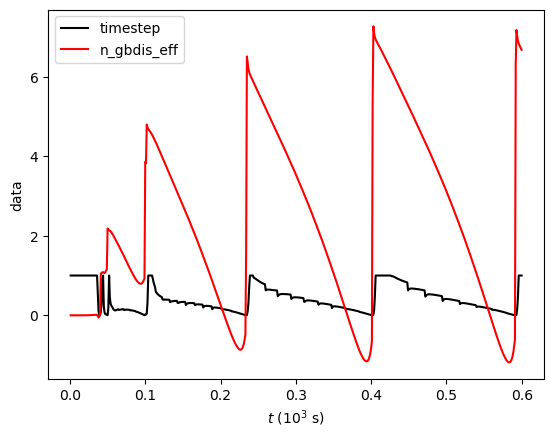

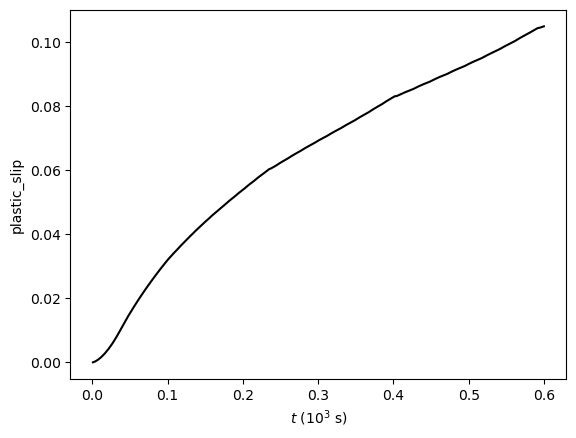

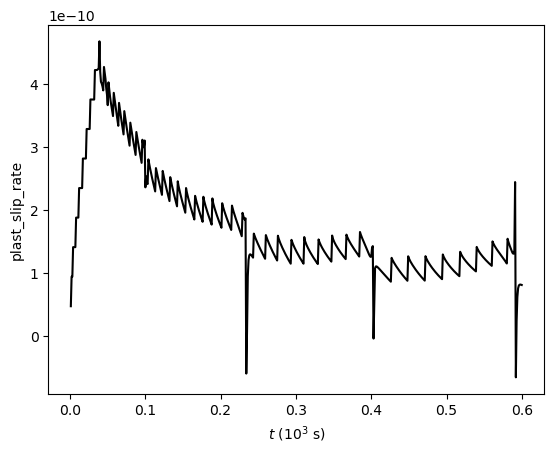

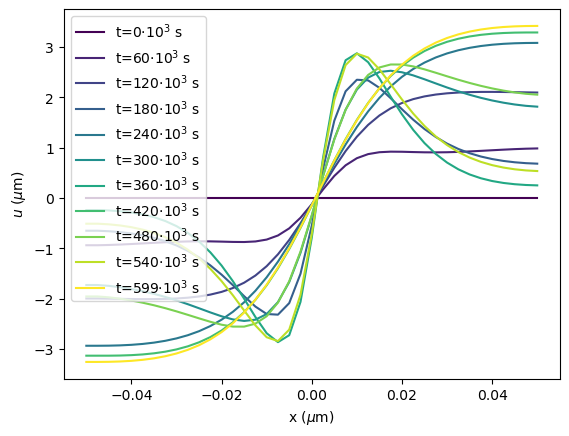

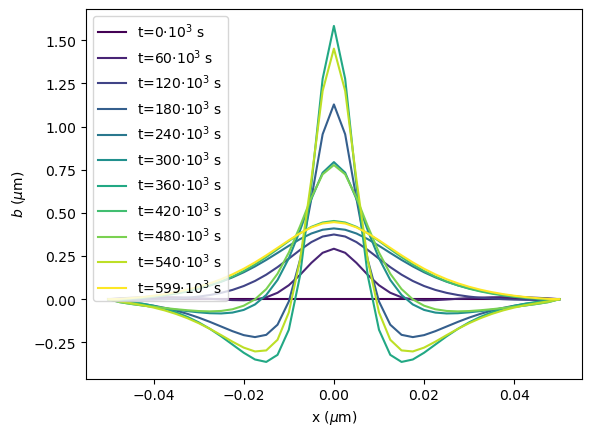

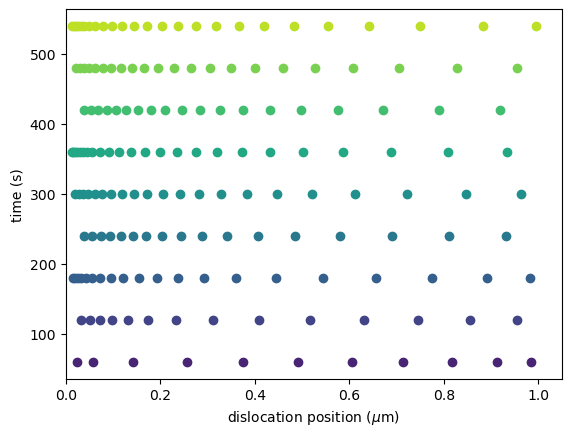

In [2]:
gbdd = dd.GB_dislocations(from_file="../examples/gbdd/pu1_tau150_T900.h5")
gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
gbdd.plot_time_series("plastic_slip")
gbdd.plot_time_series("plast_slip_rate")
gbdd.plot_field('displacement')
gbdd.plot_field('bfield')  # , file="T900_Lgb10_short.pdf")
gbdd.plot_pile_up()
                          

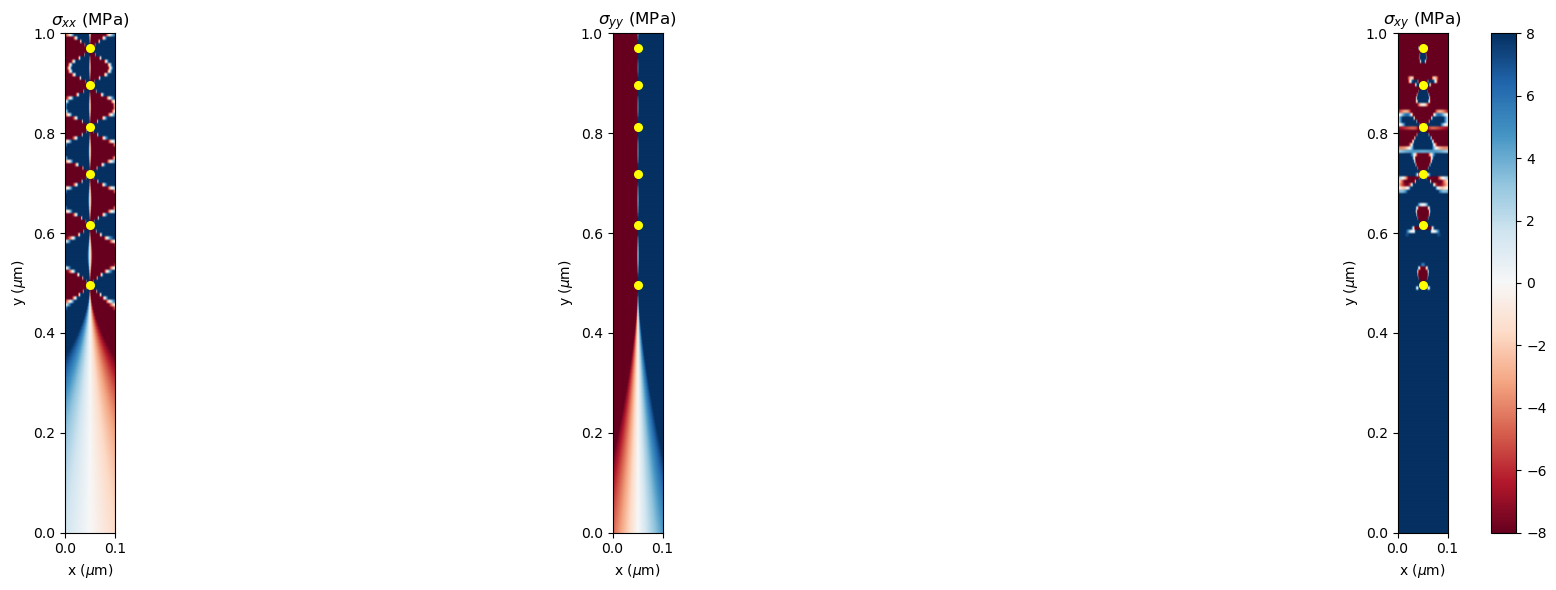

[0.4962996  0.61594943 0.71877397 0.81226908 0.89730235 0.96994668]
[-0.05039426 -0.04552851 -0.04128791 -0.03696717 -0.03147022 -0.01935193]
[-0.05039421 -0.04552848 -0.04128788 -0.03696715 -0.03147021 -0.01935187]


In [3]:
it = 20
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
yp = hh[ind]
gbf = gbdd.pu_dis['force'][it, ind]
ndis = len(yp)
xp = np.ones(ndis)*gbdd.Dgp*0.5

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, ndis, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,
                      bc="fixed")
dsl.plot_stress(show_arrows=False)
fpk = dsl.calc_force(tau0=-gbdd.tau0)
print(yp)
print(fpk[1, :])
print(gbf)

In [4]:
N = 100
res = []
for i in range(N):
    xp = np.random.rand(2)*5
    yp = np.random.rand(2)*5
    sp = np.random.rand(1)[0]*np.pi*.5
    df = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=5, LY=5,
                          bc="fixed")
    dp = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=50000, LY=50000,
                          bc="pbc")
    res.append(df.calc_force(tau0=0) / dp.calc_force(tau0=0) - 1)
    #print(dp.xpos, dp.ypos)
    #print(dp.bx, dp.by)
    #print(res[i])
print(np.max(np.abs(res)))


1.1694561625752442e-06


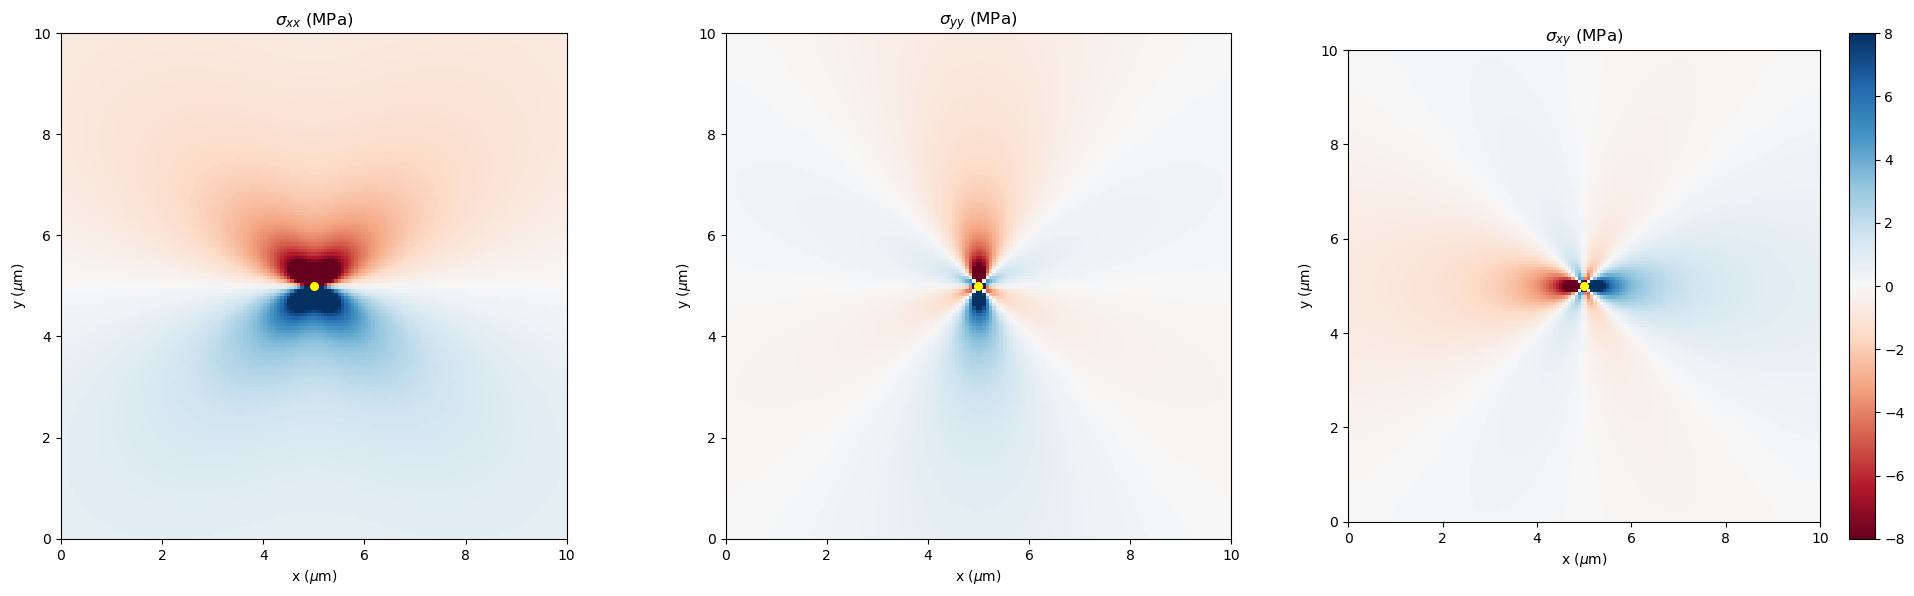

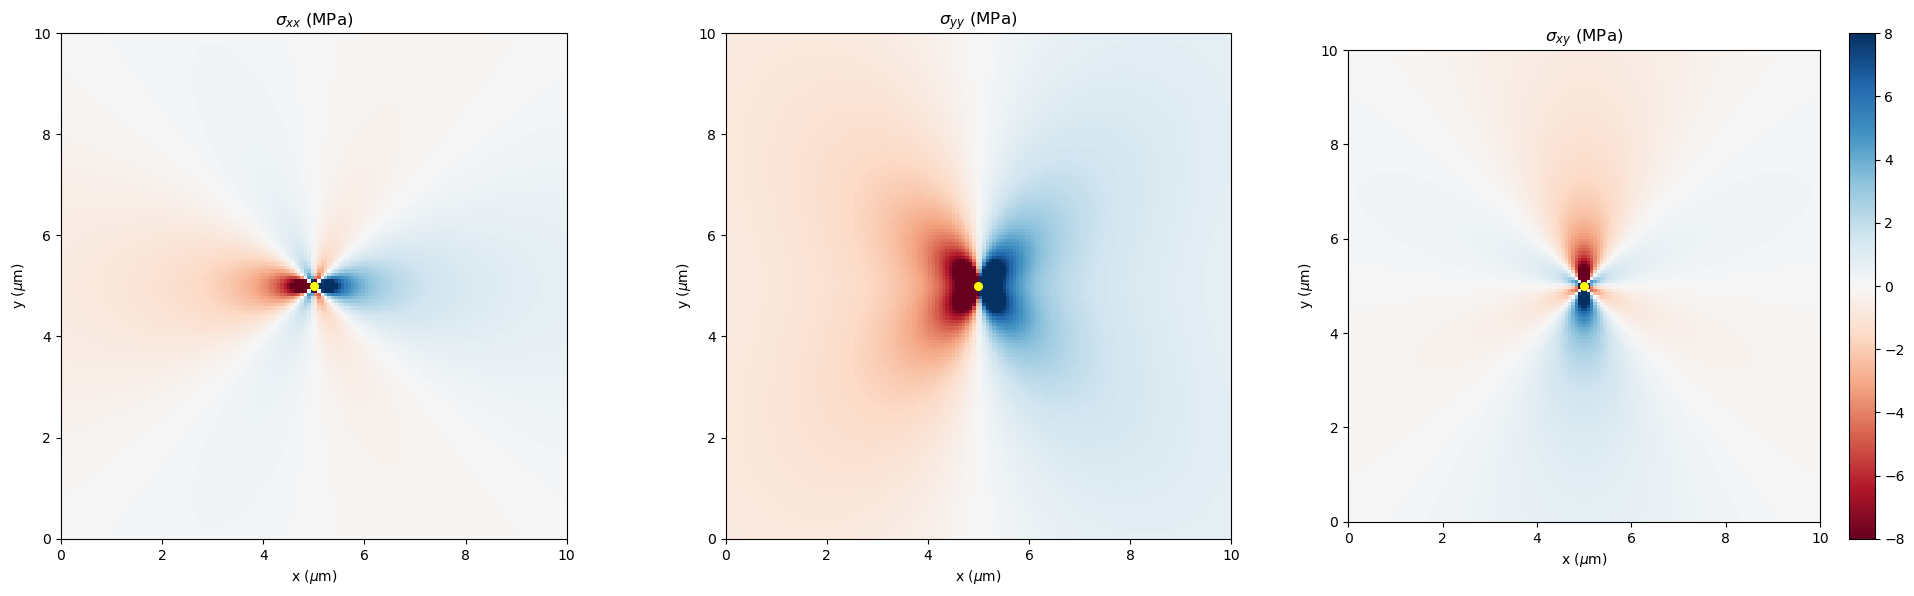

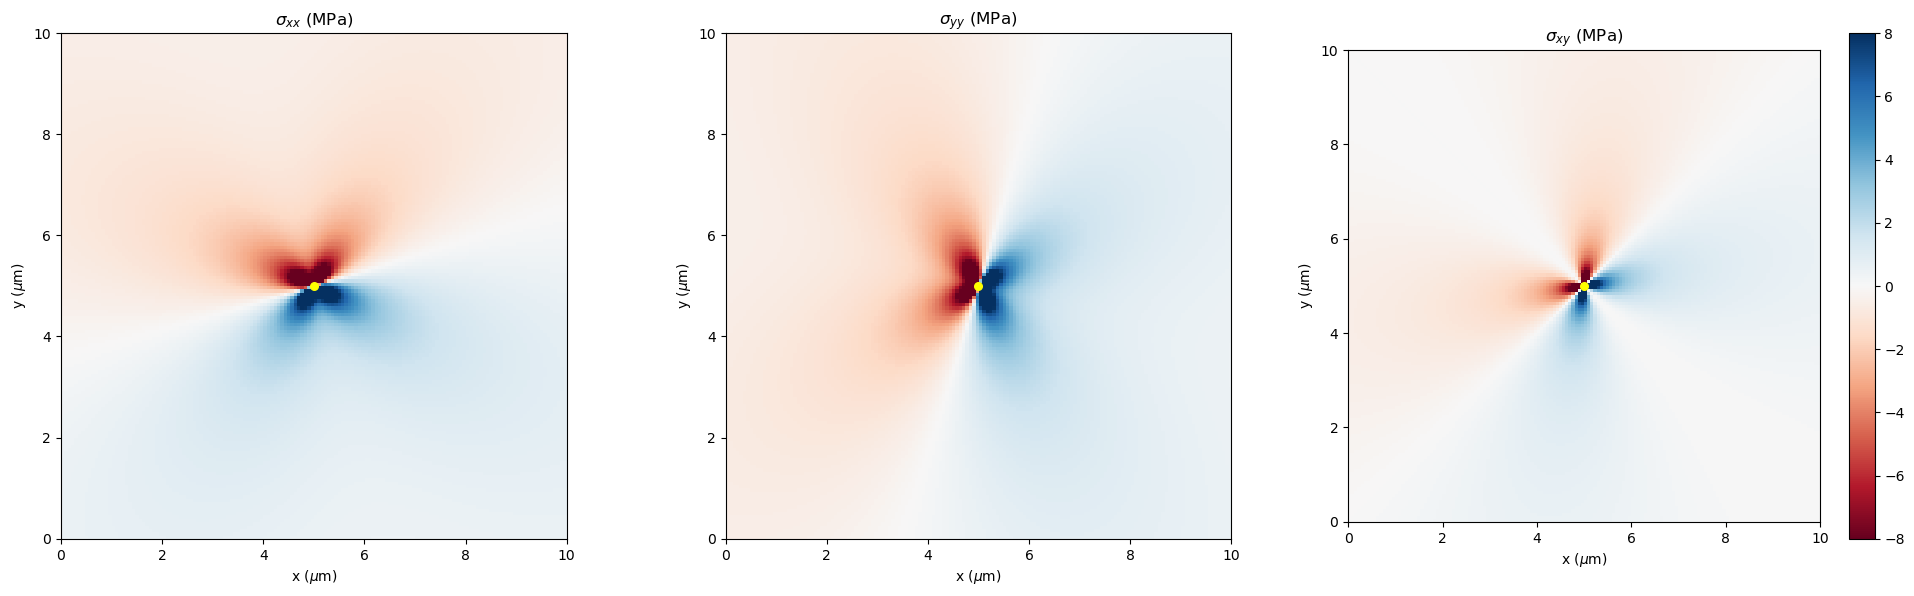

In [5]:
mu = 80.0e3          # shear modulus
nu = 0.3             # Poisson ratio
b0 = 0.2e-3          # Burgers vector norm
C = mu*b0/(2*np.pi*(1.-nu))   # Constant for dislocation stress field
f0 = 10.             # initial slip resistance

#define box 
LX = LY = 10.

#define different dislocations in box
dsl10 = dd.Dislocations(1, 0, 0., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl10.plot_stress()             # plot elastic fields

dsl01 = dd.Dislocations(1, 0, 90.*np.pi/180., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl01.plot_stress()             # plot elastic fields

dsl11 = dd.Dislocations(1, 0, 45.*np.pi/180., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl11.plot_stress()             # plot elastic fields